In [8]:
%load_ext autoreload
%autoreload 2

import cv2
import json
import pickle
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

from stereodemo.method_cre_stereo import CREStereo
from stereodemo.method_opencv_bm import StereoBM, StereoSGBM
from stereodemo.methods import Calibration, InputPair, Config
from src.disparity import normalize_disparity, show_disparity, time_call

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Cálculo de Disparidad y Reconstrucción 3D

Este notebook implementa y compara diferentes métodos de cálculo de disparidad estéreo, desde algoritmos clásicos hasta técnicas basadas en deep learning, y realiza la reconstrucción 3D de la escena.

## Métodos implementados

### 1. Métodos Básicos
- **StereoBM (Block Matching)**: Algoritmo clásico basado en correlación de bloques. Rápido pero menos preciso.

### 2. Métodos Avanzados
- **StereoSGBM (Semi-Global Block Matching)**: Optimización semi-global que mejora la consistencia espacial. Mayor precisión a costa de tiempo de cómputo.

### 3. Métodos Robustos (Deep Learning)
- **CREStereo**: Red neuronal de última generación entrenada en múltiples datasets. Excelente precisión y robustez.


## 1. Carga de Calibración y Datos


In [9]:
DATASETS_PATH = "datasets"
dataset_name = "stereo_budha_charuco"
image_index = 10

json_path = f"{DATASETS_PATH}/{dataset_name}/data/rect/stereo_calibration.json"
maps_path = f"{DATASETS_PATH}/{dataset_name}/data/stereo_maps.pkl"
calib_path = f"{DATASETS_PATH}/{dataset_name}/data/stereo_calibration.pkl"

with open(json_path, "r") as f:
    data = json.load(f)

with open(maps_path, "rb") as f:
    maps = pickle.load(f)

with open(calib_path, "rb") as f:
    calib = pickle.load(f)

calibration = Calibration(**data)
Q = maps['Q']

left_image_rect = cv2.imread(
    f"{DATASETS_PATH}/{dataset_name}/data/rect/left_{image_index:04d}.png",
    cv2.IMREAD_GRAYSCALE
)
right_image_rect = cv2.imread(
    f"{DATASETS_PATH}/{dataset_name}/data/rect/right_{image_index:04d}.png",
    cv2.IMREAD_GRAYSCALE
)

models_path = Path('models')
config = Config(models_path=models_path)

## 2. Método Básico: StereoBM (Block Matching)

Algoritmo clásico de correspondencia estéreo basado en correlación de bloques. Es el más rápido pero menos preciso en regiones con poca textura.


Tiempo de cómputo StereoBM: 50.0 ms


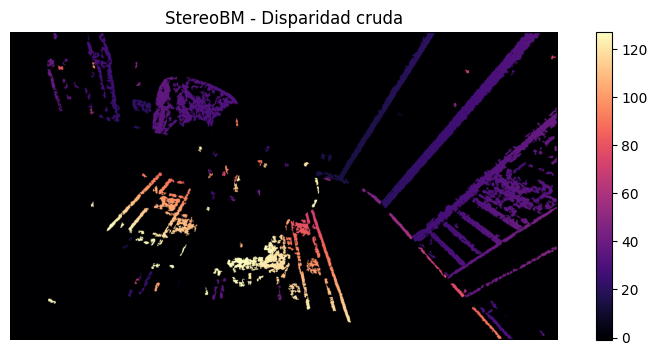

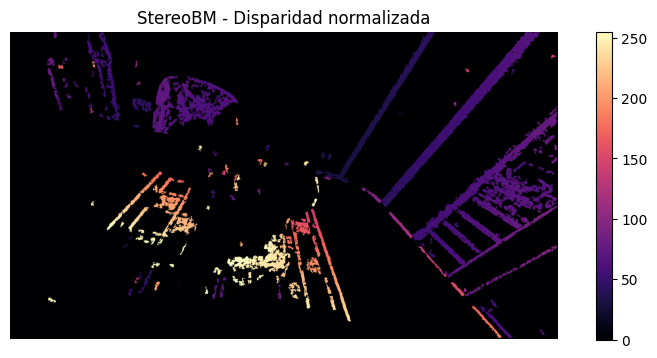

In [10]:
left_bgr = cv2.cvtColor(left_image_rect, cv2.COLOR_GRAY2BGR)
right_bgr = cv2.cvtColor(right_image_rect, cv2.COLOR_GRAY2BGR)
pair_bm = InputPair(left_bgr, right_bgr, calibration, "StereoBM")

bm_method = StereoBM(config)
disp_bm, dt_ms_bm = time_call(bm_method.compute_disparity, pair_bm)
print(f"Tiempo de cómputo StereoBM: {dt_ms_bm:.1f} ms")

show_disparity("StereoBM - Disparidad cruda", disp_bm.disparity_pixels)
show_disparity("StereoBM - Disparidad normalizada", normalize_disparity(disp_bm.disparity_pixels))

## 3. Método Avanzado: StereoSGBM (Semi-Global Block Matching)

Mejora sobre BM mediante optimización semi-global de energía. Produce mapas de disparidad más suaves y consistentes, especialmente en bordes y regiones homogéneas.


Tiempo de cómputo StereoSGBM: 2172.8 ms


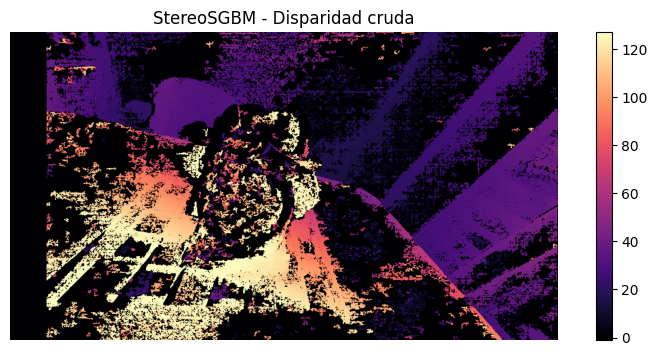

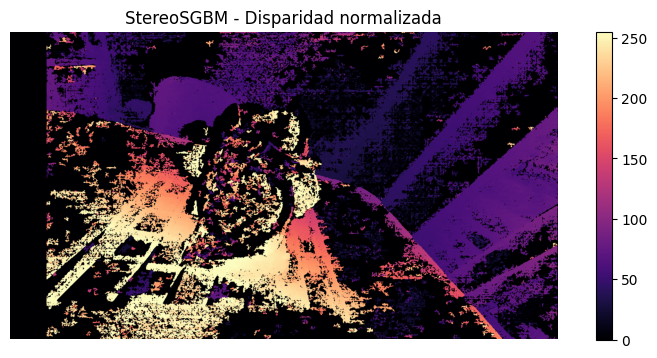

In [11]:
pair_sgbm = InputPair(left_bgr, right_bgr, calibration, "StereoSGBM")

sgbm_method = StereoSGBM(config)
disp_sgbm, dt_ms_sgbm = time_call(sgbm_method.compute_disparity, pair_sgbm)
print(f"Tiempo de cómputo StereoSGBM: {dt_ms_sgbm:.1f} ms")

show_disparity("StereoSGBM - Disparidad cruda", disp_sgbm.disparity_pixels)
show_disparity("StereoSGBM - Disparidad normalizada", normalize_disparity(disp_sgbm.disparity_pixels))

## 4. Método Robusto: CREStereo (Deep Learning)

Red neuronal convolucional de última generación. Ofrece la mejor precisión y robustez ante condiciones desafiantes (reflejos, poca textura, oclusiones).


*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/core/providers/cuda/cuda_call.cc:129 std::conditional_t<THRW, void, onnxruntime::common::Status> onnxruntime::CudaCall(ERRTYPE, const char*, const char*, SUCCTYPE, const char*, const char*, int) [with ERRTYPE = cudaError; bool THRW = true; SUCCTYPE = cudaError; std::conditional_t<THRW, void, common::Status> = void] /onnxruntime_src/onnxruntime/core/providers/cuda/cuda_call.cc:121 std::conditional_t<THRW, void, onnxruntime::common::Status> onnxruntime::CudaCall(ERRTYPE, const char*, const char*, SUCCTYPE, const char*, const char*, int) [with ERRTYPE = cudaError; bool THRW = true; SUCCTYPE = cudaError; std::conditional_t<THRW, void, common::Status> = void] CUDA failure 35: CUDA driver version is insufficient for CUDA runtime version ; GPU=-1 ; hostname=juanchi-Aspire-A315-44P ; file=/onnxruntime_src/onnxruntime/core/providers/cuda/cuda_execution_provider.cc ; line=282 ; expr=cudaSetDevice(info_.device_id); 

 

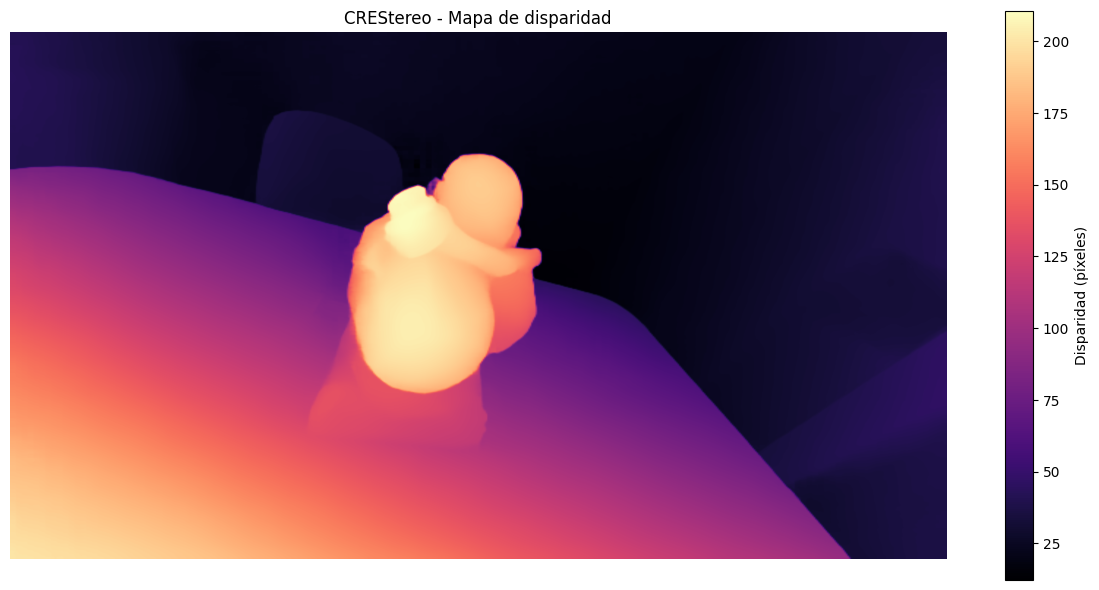

In [12]:
pair_cre = InputPair(left_image_rect, right_image_rect, calibration, "CREStereo")

cre_method = CREStereo(config)
disp_cre, dt_ms_cre = time_call(cre_method.compute_disparity, pair_cre)
print(f"Tiempo de cómputo CREStereo: {dt_ms_cre:.1f} ms")

plt.figure(figsize=(12, 6))
plt.title("CREStereo - Mapa de disparidad")
plt.imshow(disp_cre.disparity_pixels, cmap='magma')
plt.colorbar(label='Disparidad (píxeles)')
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Comparativa de Métodos

Visualización lado a lado de los tres métodos para evaluar calidad y diferencias cualitativas.


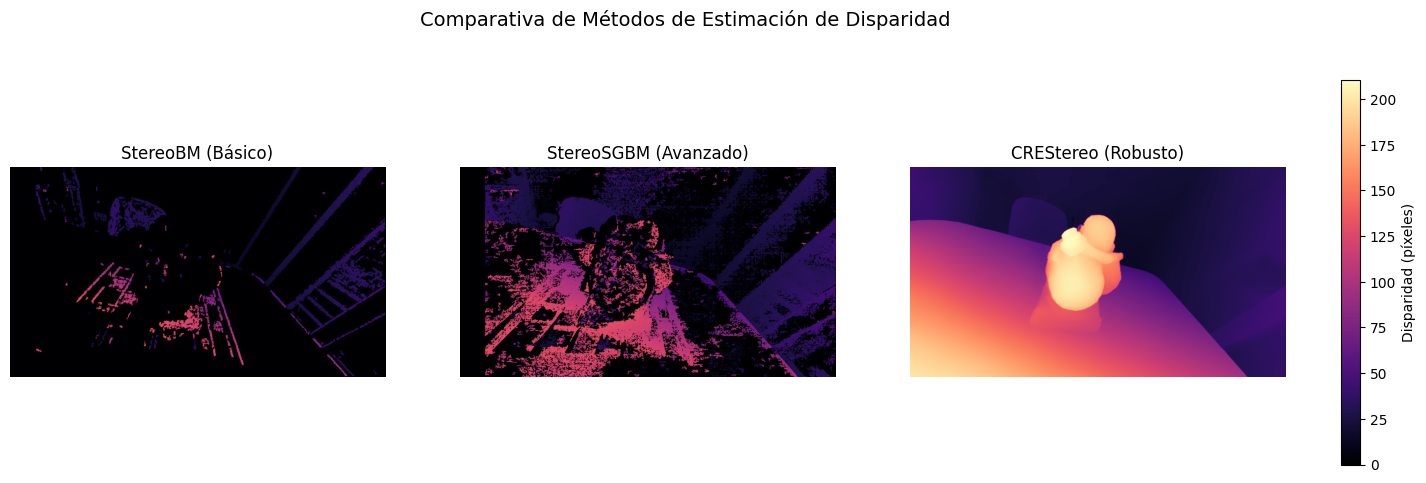


Resumen de rendimiento:
StereoBM:       50.0 ms  (1.0x)
StereoSGBM:   2172.8 ms  (43.5x)
CREStereo:    11294.8 ms  (226.0x)


In [13]:
# Comparación visual de los tres métodos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Usar una única escala de color compartida
vmin = 0
vmax = max(
    float(np.max(disp_bm.disparity_pixels)),
    float(np.max(disp_sgbm.disparity_pixels)),
    float(np.max(disp_cre.disparity_pixels)),
)

# StereoBM (Básico)
axes[0].set_title(f"StereoBM (Básico)", fontsize=12)
im0 = axes[0].imshow(disp_bm.disparity_pixels, cmap='magma', vmin=vmin, vmax=vmax)
axes[0].axis('off')

# StereoSGBM (Avanzado)
axes[1].set_title(f"StereoSGBM (Avanzado)", fontsize=12)
im1 = axes[1].imshow(disp_sgbm.disparity_pixels, cmap='magma', vmin=vmin, vmax=vmax)
axes[1].axis('off')

# CREStereo (Robusto - Deep Learning)
axes[2].set_title(f"CREStereo (Robusto)", fontsize=12)
im2 = axes[2].imshow(disp_cre.disparity_pixels, cmap='magma', vmin=vmin, vmax=vmax)
axes[2].axis('off')

# Única barra de color compartida con etiqueta
cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Disparidad (píxeles)')

plt.suptitle("Comparativa de Métodos de Estimación de Disparidad", fontsize=14, y=1.02)
plt.show()

print(f"\n{'='*60}")
print("Resumen de rendimiento:")
print(f"{'='*60}")
print(f"StereoBM:     {dt_ms_bm:6.1f} ms  (1.0x)")
print(f"StereoSGBM:   {dt_ms_sgbm:6.1f} ms  ({dt_ms_sgbm/dt_ms_bm:.1f}x)")
print(f"CREStereo:    {dt_ms_cre:6.1f} ms  ({dt_ms_cre/dt_ms_bm:.1f}x)")
print(f"{'='*60}")


## 6. Reproyección 3D y Análisis de Profundidad

A partir del mejor mapa de disparidad (CREStereo), calculamos la profundidad real de cada píxel usando la matriz de reproyección Q.


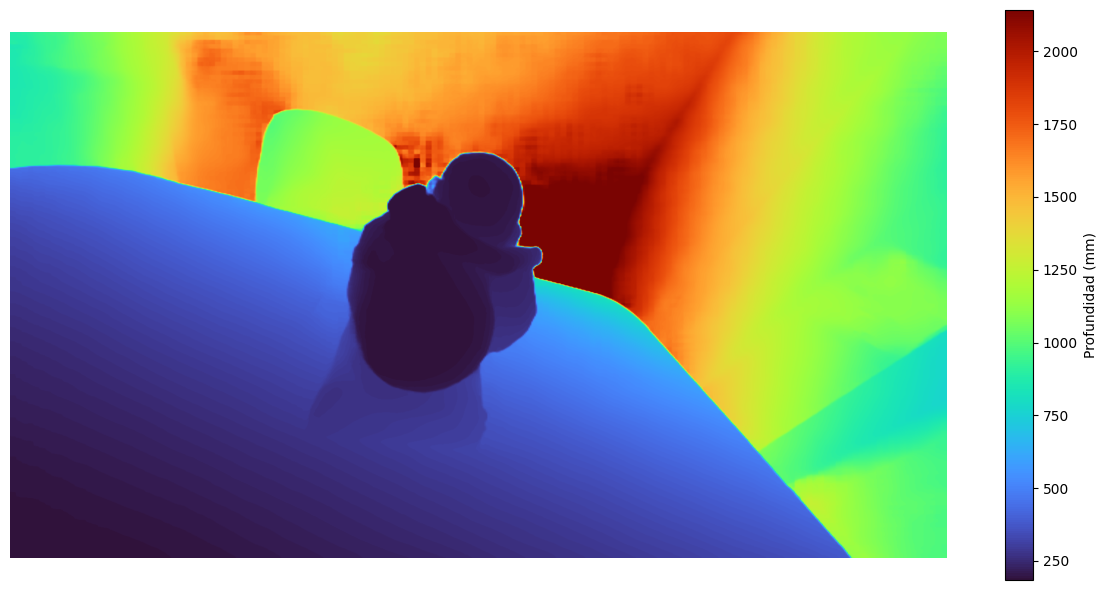

Rango de profundidad: 184.24 mm - 2142.22 mm
Puntos 3D válidos: 2,073,600


In [14]:
# Usar el mejor resultado (CREStereo) para reproyección 3D
disp = disp_cre.disparity_pixels

points3d_camera = cv2.reprojectImageTo3D(disp, Q)
depth_m = points3d_camera[:, :, 2]

mask = disp > 0
points3d_camera_valid = points3d_camera[mask]

near, far = np.nanpercentile(depth_m[mask], [2, 98])
plt.figure(figsize=(12, 6))
im = plt.imshow(depth_m, vmin=near, vmax=far, cmap='turbo')
plt.colorbar(im, label='Profundidad (mm)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Rango de profundidad: {near:.2f} mm - {far:.2f} mm")
print(f"Puntos 3D válidos: {points3d_camera_valid.shape[0]:,}")

## 7. Detección de Marcadores ArUco y Estimación de Pose

Detectamos el tablero ChArUco en la imagen para establecer un sistema de coordenadas del mundo y poder transformar los puntos 3D.


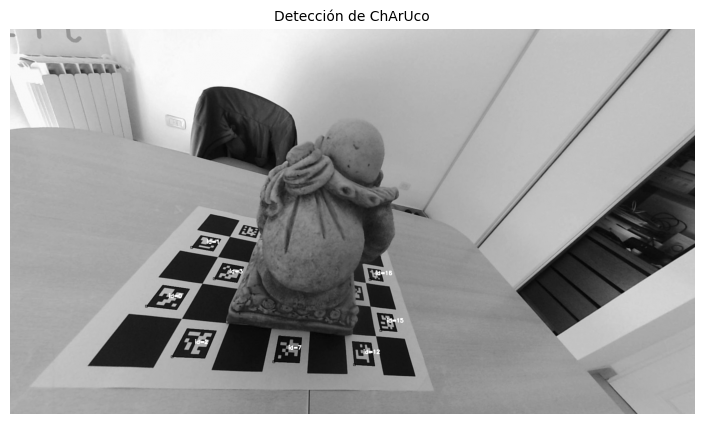

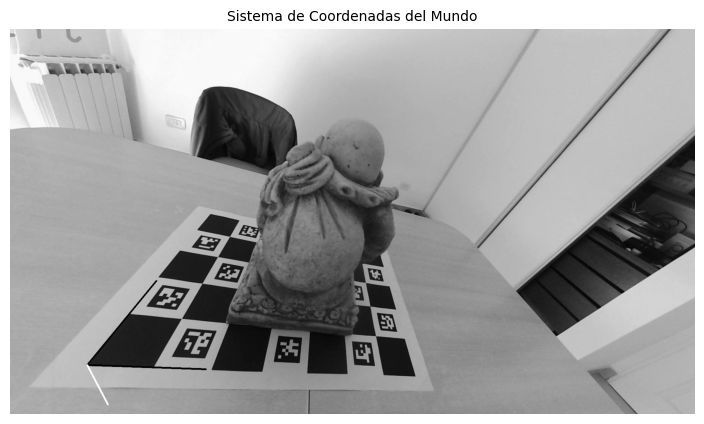

In [15]:
import src.aruco as aruco
from src.utils import plot_axis
from i308_utils import imshow

# Usar matriz intrínseca rectificada (sin distorsión)
rectified_K = maps['P1'][:, :3]
left_calibration = (rectified_K, None)

board = aruco.create_charuco_board(
    squares_x=5,
    squares_y=7,
    square_length=52.6,
    marker_length=31.3,
)

detection = aruco.detect_charuco_markers(left_image_rect, board)

img_det = aruco.draw_charuco_markers(left_image_rect, detection)
imshow(img_det, title="Detección de ChArUco", figsize=(10, 5))

pose = aruco.estimate_camera_pose_with_homography(
    left_image_rect,
    board,
    detection,
    left_calibration,
    undistort=False,
)

# Visualizar ejes del sistema de coordenadas
image_with_axis = plot_axis(left_image_rect, left_calibration, pose)
imshow(image_with_axis, title="Sistema de Coordenadas del Mundo", figsize=(10, 5))

## 8. Transformación a Coordenadas del Mundo

Transformamos los puntos 3D desde el sistema de coordenadas de la cámara al sistema de coordenadas del mundo (tablero ChArUco).


In [16]:
ok, rvec, tvec = pose

c_R_o, _ = cv2.Rodrigues(rvec)
c_T_o = np.vstack((np.column_stack((c_R_o, tvec)), [0, 0, 0, 1]))

o_T_c = np.linalg.inv(c_T_o)

points3d_camera_h = np.vstack((points3d_camera_valid.T, np.ones(points3d_camera_valid.shape[0])))
points3d_world = (o_T_c @ points3d_camera_h)[:3, :].T

print(f"Puntos transformados al sistema del mundo: {points3d_world.shape[0]:,}")
print(f"Dimensiones: {points3d_world.shape}")

Puntos transformados al sistema del mundo: 2,073,600
Dimensiones: (2073600, 3)
